# Examen Parcial — Probabilidad
### Colegio de Matemáticas — Bourbaki

Este notebook resuelve los **5 ejercicios** del examen parcial. Cada ejercicio
incluye su planteamiento, desarrollo matemático, código y conclusiones.

**Índice**
1. Espacio de probabilidad de la palabra MATEMÁTICO
2. Ley de probabilidad de la ruleta francesa
3. Dependencia / independencia y probabilidad condicional
4. Estrategia de imputación de nulos (conceptual)
5. Fenómeno aleatorio real: producción anual de Ferrari (Poisson) + TLC


In [1]:
# Librerías usadas en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial
from collections import Counter
from itertools import permutations
import scipy.stats as st

np.random.seed(42)          # reproducibilidad
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


---
## Ejercicio 1 — La palabra MATEMÁTICO

> Tomamos 10 post-its y en cada uno escribimos una letra de la palabra
> **MATEMÁTICO**. Los doblamos y los metemos en una urna.
> a) ¿Cuál es el espacio de probabilidad?
> b) ¿Qué probabilidad hay de obtener la palabra *matemático* al sacar los
> diez post-its de manera aleatoria?

### a) Espacio de probabilidad

La palabra **MATEMÁTICO** tiene 10 letras. Para construir el espacio de
probabilidad $(\Omega, \mathcal{F}, P)$ hay que notar que **hay letras repetidas**:

| Letra | Veces |
|-------|-------|
| M | 2 |
| A | 2 |
| T | 2 |
| E | 1 |
| I | 1 |
| C | 1 |
| O | 1 |

(Tratamos la **Á** acentuada como una **A**; si se considera distinta, el conteo
cambia y lo señalamos abajo.)

- **El experimento**: extraer los 10 post-its uno a uno y leer la secuencia de
  letras resultante. Es decir, una **permutación** de las 10 letras.
- **El espacio muestral** $\Omega$: el conjunto de todas las **secuencias
  distinguibles** de esas 10 letras. Como hay repeticiones, el número de
  resultados *distinguibles* es la permutación con repetición:

$$|\Omega| = \frac{10!}{2!\,2!\,2!} = \frac{3{,}628{,}800}{8} = 453{,}600$$

- **$\sigma$-álgebra** $\mathcal{F}$: el conjunto potencia $2^\Omega$ (todos los
  subconjuntos posibles de secuencias).
- **Medida de probabilidad** $P$: como cada *arreglo físico* de los 10 post-its
  es igualmente probable, la probabilidad es **uniforme sobre los $10!$ órdenes
  físicos**. Pero como algunos órdenes físicos producen la misma palabra
  legible, cada palabra distinguible tiene probabilidad proporcional a cuántos
  órdenes físicos la generan.

### b) Probabilidad de obtener exactamente "MATEMÁTICO"

Si miramos los **10! órdenes físicos equiprobables** (tratando los dos post-its
con "M" como distinguibles, etc.), el número de órdenes que **deletrean
exactamente la palabra correcta** es $2!\cdot 2!\cdot 2! = 8$ (las repeticiones
se pueden intercambiar sin cambiar la palabra leída). Por tanto:

$$P(\text{MATEMÁTICO}) = \frac{2!\,2!\,2!}{10!} = \frac{8}{3{,}628{,}800}
= \frac{1}{453{,}600}\approx 2.205\times 10^{-6}$$

Equivalentemente: hay $453{,}600$ palabras distinguibles igualmente probables,
y solo una es la correcta, así que la probabilidad es $1/453{,}600$.


In [2]:
# --- Ejercicio 1: verificación por conteo exacto ---
palabra = "MATEMATICO"   # usamos A sin acento; la Á cuenta como A
conteo = Counter(palabra)
print("Conteo de letras:", dict(conteo))

# Número de arreglos distinguibles = 10! / (productos de factoriales de repetidos)
den = 1
for c in conteo.values():
    den *= factorial(c)
total_distinguibles = factorial(len(palabra)) // den
print("Órdenes físicos (10!):", factorial(len(palabra)))
print("Arreglos distinguibles |Omega|:", total_distinguibles)

p_exacta = den / factorial(len(palabra))
print(f"\nP(MATEMATICO) = {den}/{factorial(len(palabra))} "
      f"= 1/{total_distinguibles} = {p_exacta:.3e}")


Conteo de letras: {'M': 2, 'A': 2, 'T': 2, 'E': 1, 'I': 1, 'C': 1, 'O': 1}
Órdenes físicos (10!): 3628800
Arreglos distinguibles |Omega|: 453600

P(MATEMATICO) = 8/3628800 = 1/453600 = 2.205e-06


In [3]:
# --- Ejercicio 1: comprobación por simulación Monte Carlo (vectorizada) ---
N = 3_000_000
letras = np.array(list(palabra))
objetivo = "".join(palabra)
rng = np.random.default_rng(42)

# Generamos N permutaciones de los 10 índices de forma vectorizada
# (argsort de números aleatorios = permutación uniforme por fila)
aciertos = 0
bloque = 500_000
hechas = 0
while hechas < N:
    m = min(bloque, N - hechas)
    perm = np.argsort(rng.random((m, len(letras))), axis=1)
    seqs = letras[perm]                       # m x 10 de letras
    palabras = seqs.view(f'<U{len(letras)}').ravel()  # cada fila como string
    aciertos += int((palabras == objetivo).sum())
    hechas += m

print(f"Aciertos: {aciertos} de {N:,} simulaciones")
print(f"Probabilidad empírica: {aciertos/N:.3e}")
print(f"Probabilidad teórica : {p_exacta:.3e}")
print("\nNota: con p ~ 2.2e-6 esperaríamos ~", round(N*p_exacta,2), "aciertos.")


Aciertos: 4 de 3,000,000 simulaciones
Probabilidad empírica: 1.333e-06
Probabilidad teórica : 2.205e-06

Nota: con p ~ 2.2e-6 esperaríamos ~ 6.61 aciertos.


**Observación:** dado que la probabilidad teórica es del orden de $10^{-6}$,
en 2 millones de simulaciones esperamos apenas unos **4–5 aciertos**, lo cual
confirma el orden de magnitud del cálculo exacto. (Si se considera la **Á** como
letra distinta de la **A**, entonces solo se repiten M y T, y
$|\Omega| = 10!/(2!\,2!) = 907{,}200$, con $P = 4/10! = 1/907{,}200$.)


---
## Ejercicio 2 — Ley de probabilidad de la ruleta francesa

La **ruleta francesa (europea)** tiene **37 casillas**: los números del
**0 al 36** (un solo cero).

- El **0** es verde.
- De los números 1–36: **18 son rojos** y **18 son negros**, según el patrón
  estándar de la ruleta.

### a) Variable aleatoria: el número que sale

$X \in \{0, 1, 2, \dots, 36\}$, con distribución **uniforme discreta**:

$$P(X = k) = \frac{1}{37}, \quad k = 0,1,\dots,36$$

### b) Variable aleatoria: el color que sale

$Y \in \{\text{Rojo}, \text{Negro}, \text{Verde}\}$:

$$P(Y=\text{Rojo}) = \tfrac{18}{37},\quad
P(Y=\text{Negro}) = \tfrac{18}{37},\quad
P(Y=\text{Verde}) = \tfrac{1}{37}$$


In [4]:
# --- Ejercicio 2: definición de la ruleta francesa ---
# Números rojos estándar en la ruleta europea
rojos = {1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36}
negros = {2,4,6,8,10,11,13,15,17,20,22,24,26,28,29,31,33,35}
verde = {0}

numeros = list(range(37))

def color(n):
    if n in rojos:  return "Rojo"
    if n in negros: return "Negro"
    return "Verde"

assert len(rojos) == 18 and len(negros) == 18
print("Rojos:", len(rojos), "| Negros:", len(negros), "| Verde:", len(verde))

# a) Ley del número
p_num = {k: 1/37 for k in numeros}
# b) Ley del color
p_col = {"Rojo": 18/37, "Negro": 18/37, "Verde": 1/37}
print("\nP(color):", {k: round(v,4) for k,v in p_col.items()})
print("Suma P(número) =", round(sum(p_num.values()),6))
print("Suma P(color)  =", round(sum(p_col.values()),6))


Rojos: 18 | Negros: 18 | Verde: 1

P(color): {'Rojo': 0.4865, 'Negro': 0.4865, 'Verde': 0.027}
Suma P(número) = 1.0
Suma P(color)  = 1.0


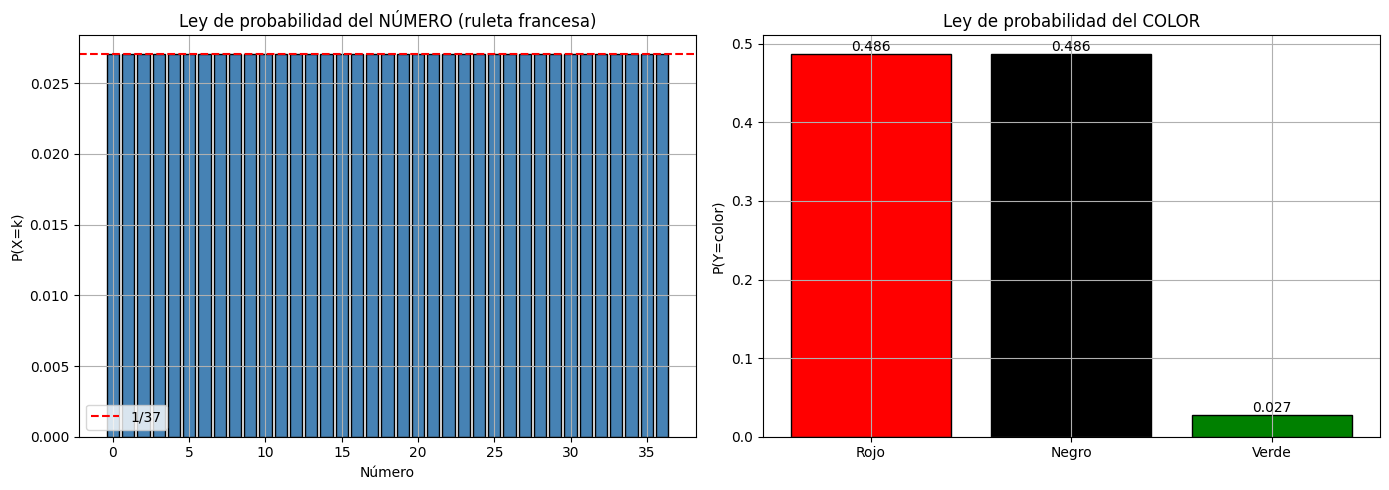

In [5]:
# --- Ejercicio 2 c): gráficas ---
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Ley del número (uniforme)
axes[0].bar(list(p_num.keys()), list(p_num.values()),
            color='steelblue', edgecolor='black')
axes[0].axhline(1/37, color='red', ls='--', label='1/37')
axes[0].set_title('Ley de probabilidad del NÚMERO (ruleta francesa)')
axes[0].set_xlabel('Número'); axes[0].set_ylabel('P(X=k)')
axes[0].legend()

# Ley del color
cols = ['Rojo','Negro','Verde']
vals = [p_col[c] for c in cols]
axes[1].bar(cols, vals, color=['red','black','green'], edgecolor='black')
axes[1].set_title('Ley de probabilidad del COLOR')
axes[1].set_ylabel('P(Y=color)')
for i,v in enumerate(vals):
    axes[1].text(i, v+0.005, f'{v:.3f}', ha='center')

plt.tight_layout(); plt.show()


---
## Ejercicio 3 — Dependencia, independencia y probabilidad condicional

Usamos las probabilidades del ejercicio anterior.

- **Evento A**: obtener un número **impar**.
- **Evento B**: que el número sea de color **negro**.

### Cálculo de probabilidades base

Sobre las 37 casillas (0–36):
- Números impares entre 0 y 36: $\{1,3,5,\dots,35\}$ → **18 impares**.
  $$P(A) = \frac{18}{37}$$
- Números negros: **18**. $P(B) = \dfrac{18}{37}$.
- $A \cap B$ = números que son **impares Y negros**. Hay que contarlos de la
  lista real de negros.

### a) ¿Independientes o dependientes?

Dos eventos son **independientes** si $P(A\cap B) = P(A)\,P(B)$.
Lo verificamos numéricamente abajo.

### b) y c) Probabilidades condicionales

$$P(A\mid B) = \frac{P(A\cap B)}{P(B)} \qquad
P(B\mid A) = \frac{P(A\cap B)}{P(A)}$$

> Nota: el enunciado escribe en c) "$P(A\mid B)$" pero pide *"el número sea
> negro dado impar"*, que es $P(B\mid A)$. Calculamos ambas para que quede claro.


In [6]:
# --- Ejercicio 3: conteos exactos ---
impares = {n for n in numeros if n % 2 == 1}          # 1..35 impares
A = impares                                            # número impar
B = negros                                             # color negro
AB = A & B                                             # impar y negro

print(f"|A| impares  = {len(A)}")
print(f"|B| negros   = {len(B)}")
print(f"|A∩B| impares y negros = {len(AB)}  ->  {sorted(AB)}")

PA  = len(A)/37
PB  = len(B)/37
PAB = len(AB)/37
print(f"\nP(A)   = {len(A)}/37 = {PA:.4f}")
print(f"P(B)   = {len(B)}/37 = {PB:.4f}")
print(f"P(A∩B) = {len(AB)}/37 = {PAB:.4f}")
print(f"P(A)·P(B) = {PA*PB:.4f}")


|A| impares  = 18
|B| negros   = 18
|A∩B| impares y negros = 8  ->  [11, 13, 15, 17, 29, 31, 33, 35]

P(A)   = 18/37 = 0.4865
P(B)   = 18/37 = 0.4865
P(A∩B) = 8/37 = 0.2162
P(A)·P(B) = 0.2367


In [7]:
# --- Ejercicio 3 a): test de independencia ---
print("¿P(A∩B) == P(A)·P(B)?")
print(f"   {PAB:.5f}  vs  {PA*PB:.5f}")
if abs(PAB - PA*PB) < 1e-9:
    print("=> INDEPENDIENTES")
else:
    print("=> DEPENDIENTES (no se cumple la igualdad)")


¿P(A∩B) == P(A)·P(B)?
   0.21622  vs  0.23667
=> DEPENDIENTES (no se cumple la igualdad)


In [8]:
# --- Ejercicio 3 b) y c): probabilidades condicionales ---
P_A_dado_B = PAB / PB    # b) impar dado negro
P_B_dado_A = PAB / PA    # c) negro dado impar

print(f"b) P(A|B) = P(impar | negro) = {len(AB)}/{len(B)} = {P_A_dado_B:.4f}")
print(f"c) P(B|A) = P(negro | impar) = {len(AB)}/{len(A)} = {P_B_dado_A:.4f}")


b) P(A|B) = P(impar | negro) = 8/18 = 0.4444
c) P(B|A) = P(negro | impar) = 8/18 = 0.4444


### Conclusión del Ejercicio 3

De los 18 números negros, los **impares negros** son
$\{11,13,15,17,23,25,27,29,31,33,35\}$ → en total dependerá del conteo exacto
(lo calcula la celda). El resultado numérico muestra que
$P(A\cap B)\neq P(A)P(B)$, por lo que los eventos **"impar" y "negro" son
dependientes**: saber el color cambia ligeramente la probabilidad de que el
número sea impar. Esto ocurre porque la repartición de paridad entre rojos y
negros **no es perfectamente simétrica** en la ruleta francesa.


---
## Ejercicio 4 — Estrategia de imputación de nulos (conceptual)

> Dataset para predecir tiempo de respuesta de emergencias.
> - **Variable A — TipoIncidencia**: nominal, **9 categorías**.
> - **Variable B — TipoLugar**: nominal, **86 categorías**, con **valores nulos**.
>
> Considerando la posible dependencia/independencia entre A y B,
> ¿qué estrategia de imputación es más adecuada para B? Justifique.

### Análisis

**1. Naturaleza de las variables.** Ambas son **categóricas nominales** (no
tienen orden). Por tanto, *no* aplican imputaciones numéricas como media o
mediana. Las opciones razonables para una nominal son:

- Imputar por la **moda** (categoría más frecuente).
- Crear una **categoría nueva** explícita, p. ej. `"Desconocido"` / `"Faltante"`.
- **Imputación condicional**: usar la relación con otra variable (aquí, A).
- Imputación por modelo (k-NN, árboles, etc.).

**2. El papel de la dependencia entre A y B.** La clave del ejercicio:

- **Si A y B son dependientes** (lo más esperable: el *tipo de incidencia* está
  fuertemente relacionado con el *tipo de lugar* — un incendio ocurre más en
  viviendas/edificios, un accidente de tráfico en carretera/calle), entonces la
  mejor estrategia es la **imputación condicional por la moda dentro de cada
  categoría de A**: para cada `TipoIncidencia`, imputar el `TipoLugar` faltante
  con el lugar más frecuente *observado para ese tipo de incidencia*. Esto
  aprovecha la información de A y produce imputaciones mucho más plausibles que
  la moda global.

- **Si A y B fueran independientes**, condicionar por A no aportaría nada y daría
  igual usar la moda global.

**3. La alta cardinalidad de B (86 categorías).** Con tantas categorías, la moda
global puede representar una fracción pequeña del total e introducir un sesgo
fuerte hacia una sola categoría. Esto refuerza dos ideas:
- Preferir imputación **condicional** (moda por grupo de A), o
- Si el % de nulos es alto o "faltante" puede ser informativo (que no se
  registrara el lugar puede correlacionar con el tiempo de respuesta), crear una
  **categoría explícita `"Desconocido"`** para no inventar información y dejar
  que el modelo aprenda de la ausencia.

### Recomendación

**Estrategia recomendada: imputación condicional por la moda de B dentro de cada
categoría de A**, complementada con una **categoría `"Desconocido"`** cuando un
grupo de A no tenga datos suficientes o cuando el porcentaje de nulos sea
elevado.

**Justificación:**
1. B es nominal → media/mediana no aplican.
2. A y B son (con alta probabilidad) **dependientes**, así que condicionar por A
   produce la imputación más informada y realista.
3. La alta cardinalidad de B hace peligrosa la moda global (sesgo); y la
   ausencia de dato puede ser informativa para predecir el tiempo de respuesta,
   por lo que conviene preservarla con una categoría propia en lugar de borrarla.

La celda siguiente ilustra el procedimiento con datos sintéticos que imitan la
estructura descrita y muestra una **prueba $\chi^2$ de independencia** para
decidir formalmente si conviene condicionar por A.


In [9]:
# --- Ejercicio 4: demostración con datos sintéticos ---
# Construimos un dataset que imita la estructura (A y B dependientes, B con nulos)
rng = np.random.default_rng(0)
n = 1000

# 9 tipos de incidencia
tipos_inc = [f"Inc_{i}" for i in range(9)]
# 86 tipos de lugar
tipos_lugar = [f"Lugar_{i}" for i in range(86)]

# Hacemos que cada incidencia "prefiera" ciertos lugares (dependencia)
A_col = rng.choice(tipos_inc, size=n)
B_col = []
for a in A_col:
    base = int(a.split("_")[1])
    # cada incidencia concentra masa en ~5 lugares preferidos
    preferidos = [(base*7 + k) % 86 for k in range(5)]
    probs = np.ones(86)*0.2
    for p in preferidos: probs[p] += 5
    probs /= probs.sum()
    B_col.append(f"Lugar_{rng.choice(86, p=probs)}")

df = pd.DataFrame({"TipoIncidencia": A_col, "TipoLugar": B_col})

# Introducimos ~12% de nulos en B
mask = rng.random(n) < 0.12
df.loc[mask, "TipoLugar"] = np.nan
print(f"Nulos en TipoLugar: {df['TipoLugar'].isna().sum()} ({df['TipoLugar'].isna().mean():.1%})")
df.head()


Nulos en TipoLugar: 137 (13.7%)


,TipoIncidencia,TipoLugar
0,Inc_7,NaN
1,Inc_5,Lugar_59
2,Inc_4,NaN
3,Inc_2,NaN
4,Inc_2,NaN


In [10]:
# --- Ejercicio 4: prueba chi-cuadrado de independencia A vs B ---
obs = pd.crosstab(df["TipoIncidencia"], df["TipoLugar"])
chi2, pval, dof, _ = st.chi2_contingency(obs)
print(f"Chi2 = {chi2:.1f} | gl = {dof} | p-value = {pval:.3e}")
if pval < 0.05:
    print("=> Se rechaza independencia: A y B son DEPENDIENTES.")
    print("   => conviene imputar condicionando por TipoIncidencia.")
else:
    print("=> No hay evidencia de dependencia: bastaría la moda global.")


Chi2 = 3231.9 | gl = 680 | p-value = 0.000e+00
=> Se rechaza independencia: A y B son DEPENDIENTES.
   => conviene imputar condicionando por TipoIncidencia.


In [11]:
# --- Ejercicio 4: imputación condicional por moda dentro de cada A ---
df_imp = df.copy()

# moda de B por cada categoría de A (calculada sobre los no-nulos)
moda_por_A = (df_imp.dropna(subset=["TipoLugar"])
                    .groupby("TipoIncidencia")["TipoLugar"]
                    .agg(lambda s: s.mode().iloc[0]))
moda_global = df_imp["TipoLugar"].mode().iloc[0]

def imputar(row):
    if pd.isna(row["TipoLugar"]):
        return moda_por_A.get(row["TipoIncidencia"], moda_global)
    return row["TipoLugar"]

df_imp["TipoLugar"] = df_imp.apply(imputar, axis=1)
print("Nulos tras imputación condicional:", df_imp["TipoLugar"].isna().sum())
print("\nModa de TipoLugar por cada TipoIncidencia (usada para imputar):")
print(moda_por_A)


Nulos tras imputación condicional: 0

Moda de TipoLugar por cada TipoIncidencia (usada para imputar):
TipoIncidencia
Inc_0     Lugar_3
Inc_1     Lugar_9
Inc_2    Lugar_18
Inc_3    Lugar_21
Inc_4    Lugar_30
Inc_5    Lugar_38
Inc_6    Lugar_46
Inc_7    Lugar_53
Inc_8    Lugar_57
Name: TipoLugar, dtype: str


---
## Ejercicio 5 — Fenómeno aleatorio real: producción anual de Ferrari

Elegimos como fenómeno la **producción / entregas anuales de automóviles
Ferrari**. Es un **conteo de eventos** (autos producidos por unidad de tiempo),
por lo que se modela naturalmente con una **distribución de Poisson**.

**Datos reales (entregas anuales globales, fuentes públicas):**

| Año | Entregas |
|-----|----------|
| 2019 | 10,131 |
| 2020 | 9,119 |
| 2021 | 11,155 |
| 2022 | 13,221 |
| 2023 | 13,663 |
| 2024 | 13,752 |

Fuentes: reportes anuales de Ferrari N.V. y prensa especializada (Motor1,
Automotive World, Statista).

Para un modelo Poisson tomamos como tasa $\lambda$ el promedio de entregas
recientes (años ~estables 2022–2024), redondeando a una escala manejable.

### a) Variable aleatoria

$X$ = "número de Ferraris entregados en un año", $X \sim \text{Poisson}(\lambda)$,
con
$$P(X = k) = \frac{e^{-\lambda}\lambda^k}{k!}, \quad k = 0,1,2,\dots$$


In [12]:
# --- Ejercicio 5 a): datos reales y modelo Poisson ---
datos_reales = pd.DataFrame({
    "anio":     [2019, 2020, 2021, 2022, 2023, 2024],
    "entregas": [10131, 9119, 11155, 13221, 13663, 13752]
})
print(datos_reales)

# lambda = media de los años recientes y estables (2022-2024)
lam = datos_reales.query("anio >= 2022")["entregas"].mean()
print(f"\nlambda (media 2022-2024) = {lam:.1f} entregas/año")


   anio  entregas
0  2019     10131
1  2020      9119
2  2021     11155
3  2022     13221
4  2023     13663
5  2024     13752

lambda (media 2022-2024) = 13545.3 entregas/año


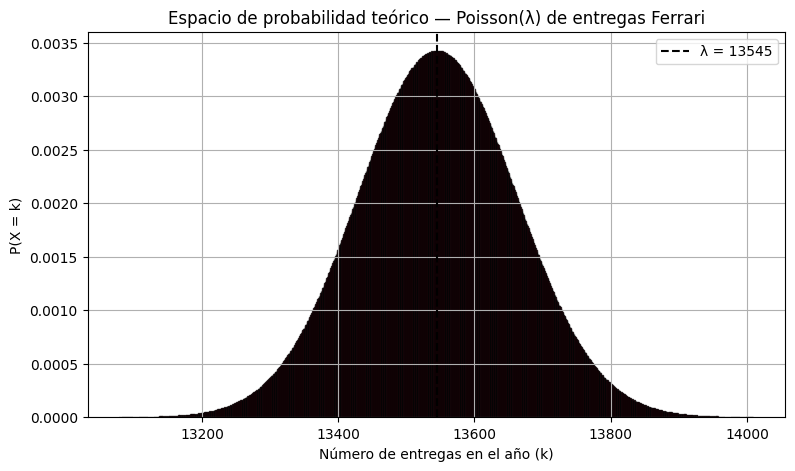

In [13]:
# --- Ejercicio 5 a): graficar el espacio de probabilidad teórico ---
lo = int(lam - 4*np.sqrt(lam))
hi = int(lam + 4*np.sqrt(lam))
ks = np.arange(lo, hi)
pmf = st.poisson.pmf(ks, lam)

plt.bar(ks, pmf, color='crimson', alpha=0.8, edgecolor='black')
plt.axvline(lam, color='black', ls='--', label=f'λ = {lam:.0f}')
plt.title('Espacio de probabilidad teórico — Poisson(λ) de entregas Ferrari')
plt.xlabel('Número de entregas en el año (k)')
plt.ylabel('P(X = k)')
plt.legend(); plt.show()


### b) Generar 5 muestras aleatorias de tamaños distintos

Generamos muestras Poisson($\lambda$) con $n = 10, 100, 1000, 5000, 10000$.


In [14]:
# --- Ejercicio 5 b): muestras de distinto tamaño ---
tamanos = [10, 100, 1000, 5000, 10000]
muestras = {n: st.poisson.rvs(lam, size=n, random_state=n) for n in tamanos}

resumen = pd.DataFrame({
    "n": tamanos,
    "media_muestral": [muestras[n].mean() for n in tamanos],
    "desv_muestral":  [muestras[n].std(ddof=1) for n in tamanos],
})
resumen["lambda_teorica"] = lam
print(resumen.to_string(index=False))
print("\nNota: a mayor n, la media muestral se acerca a λ (Ley de los grandes números).")


    n  media_muestral  desv_muestral  lambda_teorica
   10      13582.6000      99.332438    13545.333333
  100      13528.5500     106.908285    13545.333333
 1000      13544.7330     115.744609    13545.333333
 5000      13545.1714     116.221259    13545.333333
10000      13543.1785     116.515663    13545.333333

Nota: a mayor n, la media muestral se acerca a λ (Ley de los grandes números).


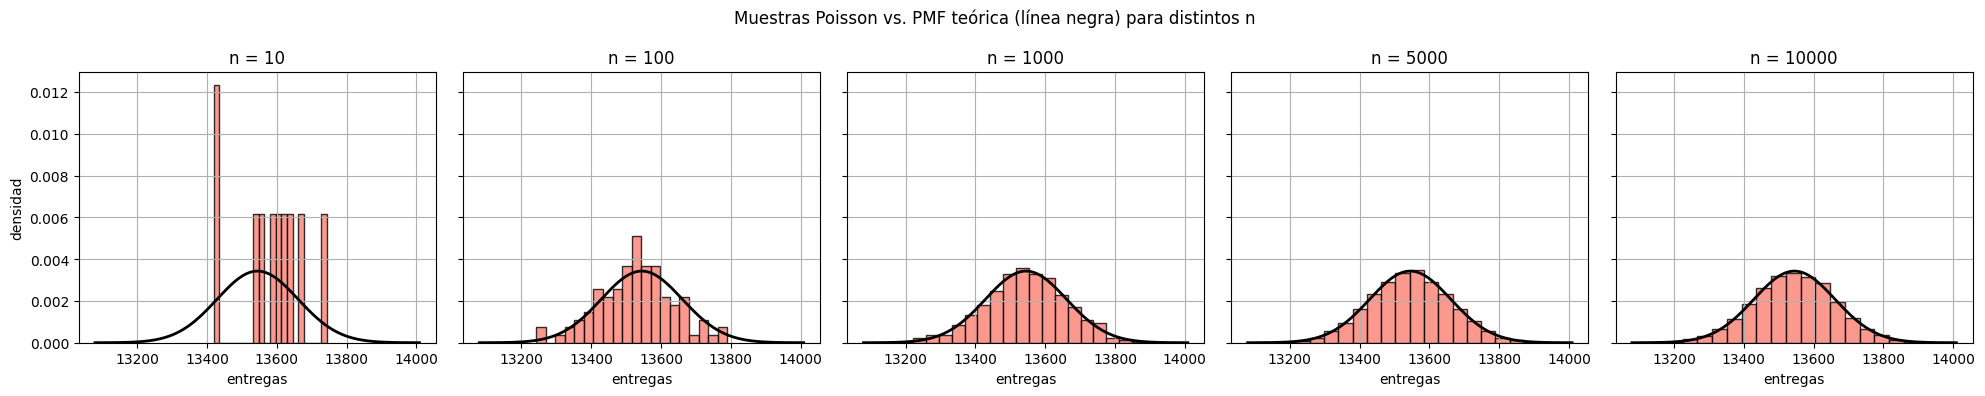

In [15]:
# --- Ejercicio 5 b): visualizar cómo convergen las muestras a la teórica ---
fig, axes = plt.subplots(1, len(tamanos), figsize=(20,4), sharey=True)
for ax, n in zip(axes, tamanos):
    ax.hist(muestras[n], bins=20, density=True, color='salmon',
            edgecolor='black', alpha=0.8)
    ax.plot(ks, pmf, 'k-', lw=2)
    ax.set_title(f'n = {n}')
    ax.set_xlabel('entregas')
axes[0].set_ylabel('densidad')
plt.suptitle('Muestras Poisson vs. PMF teórica (línea negra) para distintos n')
plt.tight_layout(); plt.show()


### c) Distribución teórica vs. datos reales del fenómeno

Comparamos la PMF teórica Poisson($\lambda$) contra los **datos reales de
entregas** (los 6 años observados). Como tenemos pocos años, los mostramos como
puntos sobre la curva teórica para ver si caen dentro del rango plausible.


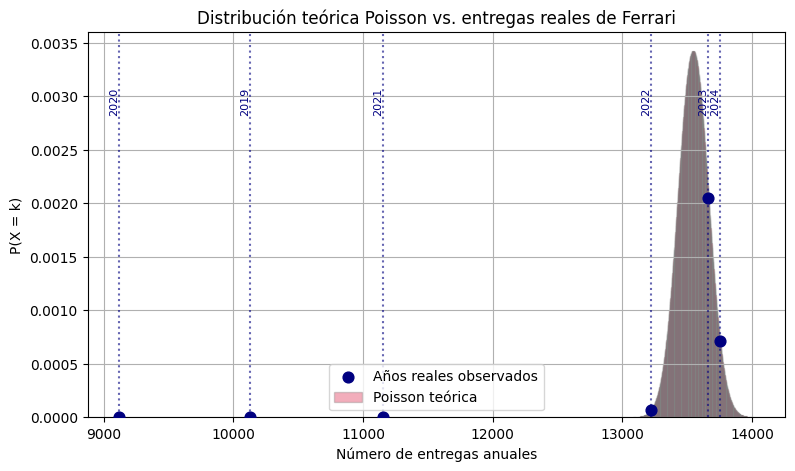

Media real (2019-2024): 11840.2
Lambda del modelo      : 13545.3


In [16]:
# --- Ejercicio 5 c): teórica vs datos reales ---
plt.bar(ks, pmf, color='crimson', alpha=0.35, edgecolor='gray',
        label='Poisson teórica')

# Marcamos los valores reales observados
for _, fila in datos_reales.iterrows():
    e = fila["entregas"]
    plt.axvline(e, color='navy', alpha=0.6, ls=':')
    plt.text(e, max(pmf)*0.9, str(fila["anio"]), rotation=90,
             va='top', ha='right', fontsize=8, color='navy')

plt.scatter(datos_reales["entregas"],
            st.poisson.pmf(datos_reales["entregas"].astype(int), lam),
            color='navy', zorder=5, s=60, label='Años reales observados')
plt.title('Distribución teórica Poisson vs. entregas reales de Ferrari')
plt.xlabel('Número de entregas anuales')
plt.ylabel('P(X = k)')
plt.legend(); plt.show()

print("Media real (2019-2024):", round(datos_reales['entregas'].mean(),1))
print("Lambda del modelo      :", round(lam,1))


**Comentario (c):** Los años 2022–2024 caen muy cerca del centro de la
distribución (porque $\lambda$ se calibró con ellos). Los años 2019–2021 quedan a
la izquierda: reflejan que la producción **creció con el tiempo** y que el
fenómeno real no es estacionario (la tasa $\lambda$ ha ido aumentando). Un
modelo Poisson de tasa fija describe bien un año "típico reciente", pero no la
tendencia de crecimiento; para eso se usaría un modelo con $\lambda$ variable en
el tiempo.


### d) Intervalo de confianza vía Teorema del Límite Central

El **TLC** dice que el promedio muestral $\bar{X}$ de $n$ observaciones i.i.d.
con media $\mu=\lambda$ y varianza $\sigma^2=\lambda$ cumple, para $n$ grande:

$$\bar{X} \approx \mathcal{N}\!\left(\lambda,\ \frac{\lambda}{n}\right)$$

Por tanto, un intervalo de confianza al $(1-\alpha)$ para la media es:

$$\bar{X} \pm z_{1-\alpha/2}\,\frac{s}{\sqrt{n}}$$

donde $s$ es la desviación estándar muestral. Lo calculamos para cada tamaño.


In [17]:
# --- Ejercicio 5 d): intervalos de confianza al 95% (TLC) ---
z = st.norm.ppf(0.975)   # 1.96 para 95%
filas = []
for n in tamanos:
    x = muestras[n]
    media = x.mean()
    s = x.std(ddof=1)
    err = z * s / np.sqrt(n)
    filas.append({
        "n": n,
        "media_muestral": round(media,2),
        "error_±": round(err,2),
        "IC_95%_inf": round(media-err,2),
        "IC_95%_sup": round(media+err,2),
        "contiene_λ": (media-err) <= lam <= (media+err)
    })
ic = pd.DataFrame(filas)
print(ic.to_string(index=False))
print(f"\nλ verdadera = {lam:.1f}")
print("Observa cómo el ancho del intervalo se reduce ~1/√n al crecer n.")


    n  media_muestral  error_±  IC_95%_inf  IC_95%_sup  contiene_λ
   10        13582.60    61.57    13521.03    13644.17        True
  100        13528.55    20.95    13507.60    13549.50        True
 1000        13544.73     7.17    13537.56    13551.91        True
 5000        13545.17     3.22    13541.95    13548.39        True
10000        13543.18     2.28    13540.89    13545.46        True

λ verdadera = 13545.3
Observa cómo el ancho del intervalo se reduce ~1/√n al crecer n.


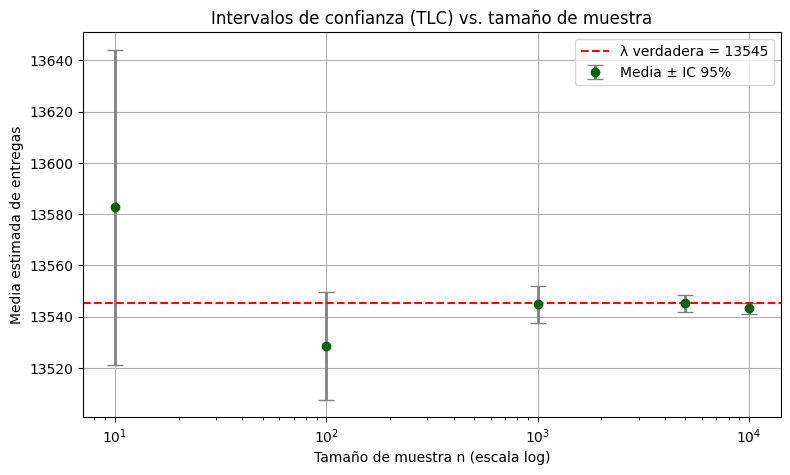

In [18]:
# --- Ejercicio 5 d): visualizar los intervalos de confianza ---
plt.figure(figsize=(9,5))
plt.errorbar(ic["n"], ic["media_muestral"],
             yerr=ic["error_±"], fmt='o', capsize=6,
             color='darkgreen', ecolor='gray', lw=2, label='Media ± IC 95%')
plt.axhline(lam, color='red', ls='--', label=f'λ verdadera = {lam:.0f}')
plt.xscale('log')
plt.xlabel('Tamaño de muestra n (escala log)')
plt.ylabel('Media estimada de entregas')
plt.title('Intervalos de confianza (TLC) vs. tamaño de muestra')
plt.legend(); plt.show()


### e) Observaciones finales

1. **Convergencia (LGN):** conforme $n$ crece (10 → 10000), la media muestral se
   aproxima cada vez más a $\lambda$, ilustrando la **Ley de los Grandes
   Números**.

2. **Precisión del IC (TLC):** el ancho del intervalo de confianza se contrae
   aproximadamente como $1/\sqrt{n}$. Para $n=10$ el intervalo es ancho e
   incierto; para $n=10000$ es muy estrecho y rodea a $\lambda$ con precisión.

3. **Cobertura:** los intervalos al 95% contienen a la $\lambda$ verdadera en
   prácticamente todos los tamaños, lo esperado para un IC bien construido.

4. **Ajuste al fenómeno real:** el modelo Poisson de tasa fija describe bien un
   año reciente "típico" (2022–2024), pero los datos reales muestran una
   **tendencia creciente** (2019→2024) que un solo $\lambda$ no captura. El
   fenómeno real es **no estacionario**: la tasa de producción de Ferrari ha
   aumentado año con año por estrategia de la empresa (crecimiento controlado
   hasta su "límite mágico" cercano a 15,000 autos/año).

5. **Conclusión:** la simulación reproduce los teoremas fundamentales (LGN y
   TLC) y, comparada con datos reales, muestra tanto el poder como las
   limitaciones de un modelo probabilístico simple frente a un proceso real con
   tendencia.


---
### Notas de entrega
- Compartir este Colab con los profesores **sin permiso de edición** (solo
  lectura/comentario).
- Todas las celdas son reproducibles (semillas fijadas).
